# Embedding-Based Models for Sentiment Analysis

In the baseline notebook (`03_baseline_models.ipynb`), we established that TF-IDF + classical ML plateaus around **0.79 macro F1**. TF-IDF treats each word independently and cannot capture word order, semantics, or context.

In this notebook, we replace TF-IDF with **dense embeddings** and combine them with **Loughran-McDonald (LM) financial dictionary features**:
1. **GloVe (Global Vectors)** — Pre-trained word vectors averaged per sentence
2. **SBERT (Sentence-BERT)** — Pre-trained transformer that produces a single embedding per sentence
3. **LM Dictionary Features** — Financial domain-specific word counts (positive, negative, uncertainty, litigious, etc.)

We pair these combined representations with classical ML models (SVM, Logistic Regression) to see how much representation quality alone improves performance.

## Setup: Imports & Data Loading

We use the same 80/20 stratified split as the baseline notebook for a fair comparison.

In [6]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

os.makedirs('../data/pkls', exist_ok=True)

# ── Load data (same split as baseline) ─────────────────────────────────────────
df = pd.read_csv('../data/processed/sentfin_strict.csv')
print(f"Dataset shape : {df.shape}")
print(f"Class distribution:\n{df['sentiment'].value_counts()}")

X = df['text'].astype(str)
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Results tracking ───────────────────────────────────────────────────────────
model_results = []

def evaluate_and_store(name, y_pred, best_params=None):
    """Evaluate predictions and append results to model_results."""
    report = classification_report(y_test, y_pred)
    entry = {
        "model"            : name,
        "best_params"      : best_params,
        "accuracy"         : accuracy_score(y_test, y_pred),
        "macro_f1"         : f1_score(y_test, y_pred, average='macro'),
        "weighted_f1"      : f1_score(y_test, y_pred, average='weighted'),
        "macro_precision"  : precision_score(y_test, y_pred, average='macro'),
        "macro_recall"     : recall_score(y_test, y_pred, average='macro'),
        "classification_report": report,
        "confusion_matrix" : confusion_matrix(y_test, y_pred),
    }
    model_results.append(entry)
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    if best_params:
        print(f"  Best params : {best_params}")
    print(f"  Accuracy    : {entry['accuracy']:.4f}")
    print(f"  Macro F1    : {entry['macro_f1']:.4f}")
    print(f"\nClassification Report:")
    print(report)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Setup complete.")

Dataset shape : (9518, 2)
Class distribution:
sentiment
neutral     3443
positive    3364
negative    2711
Name: count, dtype: int64
Setup complete.


---
## Loughran-McDonald Financial Dictionary Features

The **Loughran-McDonald Master Dictionary** classifies ~3,800 financial words into sentiment/perception categories. For each sentence we extract 8 features:

| Feature | Description |
|---------|-------------|
| `lm_negative` | Count of negative words (*loss*, *decline*) |
| `lm_positive` | Count of positive words (*growth*, *profit*) |
| `lm_uncertainty` | Count of uncertainty words (*may*, *possibly*) |
| `lm_litigious` | Count of legal/regulatory words (*lawsuit*, *violation*) |
| `lm_constraining` | Count of constraining words (*obligation*, *restrict*) |
| `lm_strong_modal` | Count of strong modal words (*will*, *shall*, *must*) |
| `lm_weak_modal` | Count of weak modal words (*could*, *might*, *may*) |
| `lm_net_sentiment` | `(positive - negative) / (positive + negative + 1)` |

These features inject **financial domain knowledge** that general embeddings lack.

In [9]:
# ── Load LM Dictionary ────────────────────────────────────────────────────────
lm_df = pd.read_csv('../data/processed/LM_Dictionary_Filtered.csv')
print(f"LM Dictionary: {lm_df.shape[0]} words, columns: {lm_df.columns.tolist()}")

# Build lookup sets for each category
# Non-zero values in each column indicate the word belongs to that category
lm_negative     = set(lm_df.loc[lm_df['Negative']     != 0, 'Word'].str.lower())
lm_positive     = set(lm_df.loc[lm_df['Positive']     != 0, 'Word'].str.lower())
lm_uncertainty  = set(lm_df.loc[lm_df['Uncertainty']   != 0, 'Word'].str.lower())
lm_litigious    = set(lm_df.loc[lm_df['Litigious']    != 0, 'Word'].str.lower())
lm_constraining = set(lm_df.loc[lm_df['Constraining'] != 0, 'Word'].str.lower())
lm_strong_modal = set(lm_df.loc[lm_df['Strong_Modal']  != 0, 'Word'].str.lower())
lm_weak_modal   = set(lm_df.loc[lm_df['Weak_Modal']    != 0, 'Word'].str.lower())

print(f"  Negative    : {len(lm_negative)} words")
print(f"  Positive    : {len(lm_positive)} words")
print(f"  Uncertainty : {len(lm_uncertainty)} words")
print(f"  Litigious   : {len(lm_litigious)} words")
print(f"  Constraining: {len(lm_constraining)} words")
print(f"  Strong Modal: {len(lm_strong_modal)} words")
print(f"  Weak Modal  : {len(lm_weak_modal)} words")

LM Dictionary: 3857 words, columns: ['Word', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong_Modal', 'Weak_Modal', 'Constraining']
  Negative    : 2345 words
  Positive    : 347 words
  Uncertainty : 297 words
  Litigious   : 901 words
  Constraining: 184 words
  Strong Modal: 19 words
  Weak Modal  : 27 words


In [10]:
def extract_lm_features(text):
    """Extract Loughran-McDonald dictionary features from a text string."""
    words = text.lower().split()
    neg   = sum(1 for w in words if w in lm_negative)
    pos   = sum(1 for w in words if w in lm_positive)
    unc   = sum(1 for w in words if w in lm_uncertainty)
    lit   = sum(1 for w in words if w in lm_litigious)
    con   = sum(1 for w in words if w in lm_constraining)
    s_mod = sum(1 for w in words if w in lm_strong_modal)
    w_mod = sum(1 for w in words if w in lm_weak_modal)
    net   = (pos - neg) / (pos + neg + 1)  # avoid division by zero
    return [neg, pos, unc, lit, con, s_mod, w_mod, net]

print("Extracting LM features for training set...")
X_train_lm = np.array([extract_lm_features(t) for t in X_train])
print("Extracting LM features for test set...")
X_test_lm  = np.array([extract_lm_features(t) for t in X_test])

lm_feat_names = ['lm_neg', 'lm_pos', 'lm_unc', 'lm_lit', 'lm_con', 'lm_strong', 'lm_weak', 'lm_net']
print(f"LM features shape: train {X_train_lm.shape}, test {X_test_lm.shape}")

# Quick sanity check: show mean feature values per sentiment class
lm_check = pd.DataFrame(X_train_lm, columns=lm_feat_names)
lm_check['sentiment'] = y_train.values
display(lm_check.groupby('sentiment').mean().round(3))

Extracting LM features for training set...
Extracting LM features for test set...
LM features shape: train (7614, 8), test (1904, 8)


,lm_neg,lm_pos,lm_unc,lm_lit,lm_con,lm_strong,lm_weak,lm_net
sentiment,,,,,,,,
negative,0.421,0.041,0.089,0.018,0.008,0.013,0.060,-0.176
neutral,0.093,0.042,0.075,0.029,0.019,0.026,0.058,-0.023
positive,0.067,0.207,0.065,0.007,0.005,0.026,0.051,0.066


---
## Part 1 — GloVe Embeddings + LM Features

**GloVe** (Global Vectors for Word Representation) maps each word to a 200-dimensional dense vector encoding its semantic meaning. We represent each sentence as the **mean of its word vectors**, then concatenate with the 8 LM dictionary features.

Final feature vector: `[200-dim GloVe mean] + [8 LM features] = 208 dimensions`

In [11]:
import gensim.downloader as api

# Download pre-trained GloVe vectors (this may take a few minutes the first time)
print("Loading GloVe vectors (glove-twitter-200)...")
glove_model = api.load('glove-twitter-200')
print(f"Loaded {len(glove_model)} word vectors with {glove_model.vector_size} dimensions.")

Loading GloVe vectors (glove-twitter-200)...
[==================================================] 100.0% 758.5/758.5MB downloaded
Loaded 1193514 word vectors with 200 dimensions.


In [12]:
def text_to_glove(text, model, dim=200):
    """Convert a text string to a mean GloVe embedding."""
    words = text.lower().split()
    vectors = [model[w] for w in words if w in model]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

print("Computing GloVe embeddings for training set...")
X_train_glove = np.array([text_to_glove(t, glove_model) for t in X_train])
print("Computing GloVe embeddings for test set...")
X_test_glove  = np.array([text_to_glove(t, glove_model) for t in X_test])

# Concatenate GloVe + LM features
X_train_glove_lm = np.hstack([X_train_glove, X_train_lm])
X_test_glove_lm  = np.hstack([X_test_glove,  X_test_lm])

print(f"GloVe only  : {X_train_glove.shape}")
print(f"GloVe + LM  : {X_train_glove_lm.shape}")

Computing GloVe embeddings for training set...
Computing GloVe embeddings for test set...
GloVe only  : (7614, 200)
GloVe + LM  : (7614, 208)


### Model 1 — GloVe + LM + Logistic Regression

In [13]:
glove_lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

glove_lr_params = {
    'clf__C'      : [0.1, 1.0, 10.0, 50.0],
    'clf__solver' : ['lbfgs', 'saga'],
}

glove_lr_gs = GridSearchCV(
    glove_lr_pipeline, glove_lr_params,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
glove_lr_gs.fit(X_train_glove_lm, y_train)

joblib.dump(glove_lr_gs.best_estimator_, '../data/pkls/glove_lm_lr.pkl')
y_pred = glove_lr_gs.best_estimator_.predict(X_test_glove_lm)
evaluate_and_store("GloVe + LM + Logistic Regression", y_pred, glove_lr_gs.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits

  GloVe + LM + Logistic Regression
  Best params : {'clf__C': 50.0, 'clf__solver': 'lbfgs'}
  Accuracy    : 0.7269
  Macro F1    : 0.7259

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.68      0.71       542
     neutral       0.72      0.73      0.73       689
    positive       0.72      0.76      0.74       673

    accuracy                           0.73      1904
   macro avg       0.73      0.72      0.73      1904
weighted avg       0.73      0.73      0.73      1904



### Model 2 — GloVe + LM + SVM (RBF Kernel)

In [14]:
glove_svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(random_state=42, kernel='rbf'))
])

glove_svm_params = {
    'clf__C'     : [0.1, 1.0, 10.0, 50.0],
    'clf__gamma' : ['scale', 'auto', 0.01, 0.001],
}

glove_svm_gs = GridSearchCV(
    glove_svm_pipeline, glove_svm_params,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
glove_svm_gs.fit(X_train_glove_lm, y_train)

joblib.dump(glove_svm_gs.best_estimator_, '../data/pkls/glove_lm_svm.pkl')
y_pred = glove_svm_gs.best_estimator_.predict(X_test_glove_lm)
evaluate_and_store("GloVe + LM + RBF SVM", y_pred, glove_svm_gs.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

  GloVe + LM + RBF SVM
  Best params : {'clf__C': 1.0, 'clf__gamma': 'scale'}
  Accuracy    : 0.7773
  Macro F1    : 0.7757

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.72      0.76       542
     neutral       0.76      0.81      0.78       689
    positive       0.78      0.79      0.79       673

    accuracy                           0.78      1904
   macro avg       0.78      0.77      0.78      1904
weighted avg       0.78      0.78      0.78      1904



---
## Part 2 — SBERT Embeddings + LM Features

**SBERT** (Sentence-BERT) uses a pre-trained transformer to generate a single, contextualized embedding for an entire sentence. Unlike GloVe (which averages independent word vectors), SBERT understands:
- **Word order**: *"profit decline"* ≠ *"decline profit"*
- **Context**: *"not good"* ≠ *"good"*
- **Full sentence meaning**: captures the overall semantic intent

We use `all-MiniLM-L6-v2` (384 dimensions, fast and accurate) and concatenate with LM features.

Final feature vector: `[384-dim SBERT] + [8 LM features] = 392 dimensions`

In [15]:
from sentence_transformers import SentenceTransformer

print("Loading SBERT model (all-MiniLM-L6-v2)...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding training set...")
X_train_sbert = sbert_model.encode(X_train.tolist(), show_progress_bar=True, batch_size=64)
print("Encoding test set...")
X_test_sbert  = sbert_model.encode(X_test.tolist(), show_progress_bar=True, batch_size=64)

# Concatenate SBERT + LM features
X_train_sbert_lm = np.hstack([X_train_sbert, X_train_lm])
X_test_sbert_lm  = np.hstack([X_test_sbert,  X_test_lm])

print(f"SBERT only  : {X_train_sbert.shape}")
print(f"SBERT + LM  : {X_train_sbert_lm.shape}")

d:\financial statment analyzer\financialvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SBERT model (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2738.73it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding training set...


Batches: 100%|██████████| 119/119 [00:38<00:00,  3.11it/s]


Encoding test set...


Batches: 100%|██████████| 30/30 [00:10<00:00,  2.97it/s]

SBERT only  : (7614, 384)
SBERT + LM  : (7614, 392)


### Model 3 — SBERT + LM + Logistic Regression

In [16]:
sbert_lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

sbert_lr_params = {
    'clf__C'      : [0.1, 1.0, 10.0, 50.0, 100.0],
    'clf__solver' : ['lbfgs', 'saga'],
}

sbert_lr_gs = GridSearchCV(
    sbert_lr_pipeline, sbert_lr_params,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
sbert_lr_gs.fit(X_train_sbert_lm, y_train)

joblib.dump(sbert_lr_gs.best_estimator_, '../data/pkls/sbert_lm_lr.pkl')
y_pred = sbert_lr_gs.best_estimator_.predict(X_test_sbert_lm)
evaluate_and_store("SBERT + LM + Logistic Regression", y_pred, sbert_lr_gs.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

  SBERT + LM + Logistic Regression
  Best params : {'clf__C': 0.1, 'clf__solver': 'lbfgs'}
  Accuracy    : 0.7668
  Macro F1    : 0.7668

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.75      0.77       542
     neutral       0.76      0.76      0.76       689
    positive       0.75      0.79      0.77       673

    accuracy                           0.77      1904
   macro avg       0.77      0.77      0.77      1904
weighted avg       0.77      0.77      0.77      1904



### Model 4 — SBERT + LM + SVM (RBF Kernel)

In [17]:
sbert_svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(random_state=42, kernel='rbf'))
])

sbert_svm_params = {
    'clf__C'     : [1.0, 10.0, 50.0, 100.0],
    'clf__gamma' : ['scale', 'auto', 0.01, 0.001],
}

sbert_svm_gs = GridSearchCV(
    sbert_svm_pipeline, sbert_svm_params,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1
)
sbert_svm_gs.fit(X_train_sbert_lm, y_train)

joblib.dump(sbert_svm_gs.best_estimator_, '../data/pkls/sbert_lm_svm.pkl')
y_pred = sbert_svm_gs.best_estimator_.predict(X_test_sbert_lm)
evaluate_and_store("SBERT + LM + RBF SVM", y_pred, sbert_svm_gs.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

  SBERT + LM + RBF SVM
  Best params : {'clf__C': 10.0, 'clf__gamma': 'scale'}
  Accuracy    : 0.8099
  Macro F1    : 0.8098

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.80      0.81       542
     neutral       0.80      0.81      0.80       689
    positive       0.81      0.82      0.82       673

    accuracy                           0.81      1904
   macro avg       0.81      0.81      0.81      1904
weighted avg       0.81      0.81      0.81      1904



---
## Results Summary

Comparison of all embedding-based models against the best TF-IDF baseline (SVM @ 0.7898 macro F1).

In [18]:
# Add baseline best result for comparison
baseline_best = {
    "model": "[Baseline] TF-IDF + SVM",
    "best_params": None,
    "accuracy": 0.7920,
    "macro_f1": 0.7898,
    "weighted_f1": 0.7917,
    "macro_precision": 0.7936,
    "macro_recall": 0.7881,
}

all_results = [baseline_best] + model_results

summary_df = pd.DataFrame([{
    "Model"          : r["model"],
    "Accuracy"       : round(r["accuracy"],        4),
    "Macro F1"       : round(r["macro_f1"],        4),
    "Weighted F1"    : round(r["weighted_f1"],     4),
    "Macro Precision": round(r["macro_precision"], 4),
    "Macro Recall"   : round(r["macro_recall"],    4),
} for r in all_results]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

display(summary_df)

,Model,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0,SBERT + LM + RBF SVM,0.8099,0.8098,0.8099,0.8106,0.8092
1,[Baseline] TF-IDF + SVM,0.7920,0.7898,0.7917,0.7936,0.7881
2,GloVe + LM + RBF SVM,0.7773,0.7757,0.7770,0.7796,0.7736
3,SBERT + LM + Logistic Regression,0.7668,0.7668,0.7668,0.7688,0.7655
4,GloVe + LM + Logistic Regression,0.7269,0.7259,0.7267,0.7290,0.7241


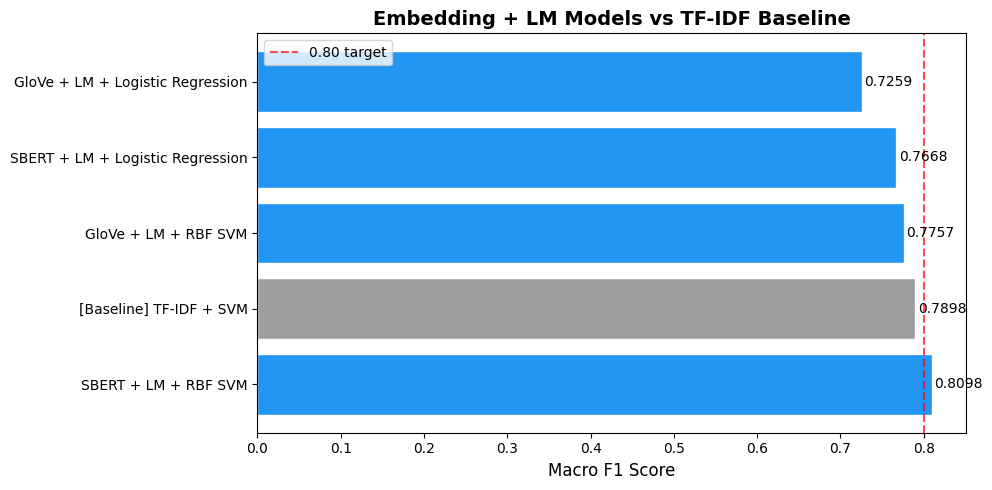

In [19]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3' if 'Baseline' not in m else '#9E9E9E' for m in summary_df['Model']]
bars = ax.barh(summary_df['Model'], summary_df['Macro F1'], color=colors, edgecolor='white')
ax.set_xlabel('Macro F1 Score', fontsize=12)
ax.set_title('Embedding + LM Models vs TF-IDF Baseline', fontsize=14, fontweight='bold')
ax.axvline(x=0.80, color='red', linestyle='--', alpha=0.7, label='0.80 target')
ax.legend()

for bar, val in zip(bars, summary_df['Macro F1']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()